In [1]:
import pandas as pd
import numpy as np

In [2]:
import pandas as pd
import seaborn as sns

In [3]:
from pandas import read_csv

df = read_csv(r'C:\Users\HP\Downloads\titanic.csv')

In [4]:
# Numerical vs Categorical Features

numerical_features = df.select_dtypes(include=['int64', 'float64']).columns
categorical_features = df.select_dtypes(include=['object']).columns

print("Numerical Features:", list(numerical_features))
print("Categorical Features:", list(categorical_features))

Numerical Features: ['PassengerId', 'Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare']
Categorical Features: ['Name', 'Sex', 'Ticket', 'Cabin', 'Embarked']


C:\Users\HP\AppData\Local\Temp\ipykernel_5708\2398746110.py:4: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = df.select_dtypes(include=['object']).columns


In [5]:
import numpy as np

# Select numerical columns
numerical_cols = df.select_dtypes(include=[np.number]).columns.tolist()

# Compute correlation matrix
corr_matrix = df[numerical_cols].corr()

# Display the correlation matrix
print(corr_matrix)

             PassengerId  Survived    Pclass       Age     SibSp     Parch  \
PassengerId     1.000000 -0.005007 -0.035144  0.036847 -0.057527 -0.001652   
Survived       -0.005007  1.000000 -0.338481 -0.077221 -0.035322  0.081629   
Pclass         -0.035144 -0.338481  1.000000 -0.369226  0.083081  0.018443   
Age             0.036847 -0.077221 -0.369226  1.000000 -0.308247 -0.189119   
SibSp          -0.057527 -0.035322  0.083081 -0.308247  1.000000  0.414838   
Parch          -0.001652  0.081629  0.018443 -0.189119  0.414838  1.000000   
Fare            0.012658  0.257307 -0.549500  0.096067  0.159651  0.216225   

                 Fare  
PassengerId  0.012658  
Survived     0.257307  
Pclass      -0.549500  
Age          0.096067  
SibSp        0.159651  
Parch        0.216225  
Fare         1.000000  


In [6]:
print("\n--- Correlation Matrix ---")
print(corr_matrix)


--- Correlation Matrix ---
             PassengerId  Survived    Pclass       Age     SibSp     Parch  \
PassengerId     1.000000 -0.005007 -0.035144  0.036847 -0.057527 -0.001652   
Survived       -0.005007  1.000000 -0.338481 -0.077221 -0.035322  0.081629   
Pclass         -0.035144 -0.338481  1.000000 -0.369226  0.083081  0.018443   
Age             0.036847 -0.077221 -0.369226  1.000000 -0.308247 -0.189119   
SibSp          -0.057527 -0.035322  0.083081 -0.308247  1.000000  0.414838   
Parch          -0.001652  0.081629  0.018443 -0.189119  0.414838  1.000000   
Fare            0.012658  0.257307 -0.549500  0.096067  0.159651  0.216225   

                 Fare  
PassengerId  0.012658  
Survived     0.257307  
Pclass      -0.549500  
Age          0.096067  
SibSp        0.159651  
Parch        0.216225  
Fare         1.000000  


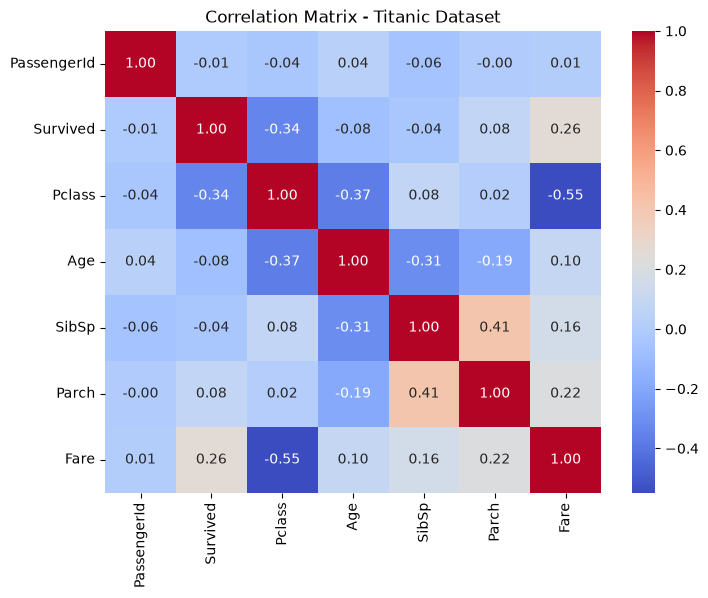

In [7]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Select numerical columns
numerical_cols = df.select_dtypes(include=[np.number]).columns.tolist()

# Compute correlation matrix
corr_matrix = df[numerical_cols].corr()

# Plot heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix - Titanic Dataset')
plt.show()

In [10]:
import matplotlib.pyplot as plt
plt.figure(figsize=(15,15))
sns.heatmap(
corr_matrix,
annot=True,
cmap="coolwarm",
fmt=".2f",
vmin=-1,
vmax=1,
square=True,
linewidths=0.5
)
plt.title("Correlation Heatmap of Numerical Features", fontsize=14, fontweight="bold")
plt.tight_layout()

# Export Heatmap
import os
output_dir = r"C:\Users\HP\Downloads"
heatmap_path = os.path.join(output_dir, "correlation_heatmap.png")
plt.savefig(heatmap_path, dpi=300)
plt.close()
print(f"Exported heatmap to: {heatmap_path}")

Exported heatmap to: C:\Users\HP\Downloads\correlation_heatmap.png


In [11]:
print(os.getcwd())

c:\Users\HP\OneDrive\Desktop\Placement Predection System\notebooks


In [12]:
import os
import matplotlib.pyplot as plt
import seaborn as sns

# Target column
target_col = "Survived"

if target_col in df.columns:
    for col in numerical_cols:
        # Skip plotting the target column against itself
        if col == target_col:
            continue

        plt.figure(figsize=(6, 5))

        sns.boxplot(
            x=target_col,
            y=col,
            data=df,
            palette="Set2",
            hue=target_col,
            legend=False
        )

        plt.title(f"{col} vs {target_col}", fontsize=12, fontweight="bold")
        plt.xlabel(target_col)
        plt.ylabel(col)
        plt.tight_layout()

        # Save the boxplot
        boxplot_filename = f"boxplot_{col}_vs_{target_col}.png"

        # Complete file path
        boxplot_path = os.path.join(output_dir, boxplot_filename)

        # Save figure
        plt.savefig(boxplot_path, dpi=300, bbox_inches="tight")

        # Close figure
        plt.close()

        print(f"Exported boxplot to: {boxplot_path}")

else:
    print(f"\nTarget column '{target_col}' not found in dataset. Skipping boxplots.")

print("\nAll EDA tasks completed successfully!")

Exported boxplot to: C:\Users\HP\Downloads\boxplot_PassengerId_vs_Survived.png
Exported boxplot to: C:\Users\HP\Downloads\boxplot_Pclass_vs_Survived.png
Exported boxplot to: C:\Users\HP\Downloads\boxplot_Age_vs_Survived.png
Exported boxplot to: C:\Users\HP\Downloads\boxplot_SibSp_vs_Survived.png
Exported boxplot to: C:\Users\HP\Downloads\boxplot_Parch_vs_Survived.png
Exported boxplot to: C:\Users\HP\Downloads\boxplot_Fare_vs_Survived.png

All EDA tasks completed successfully!


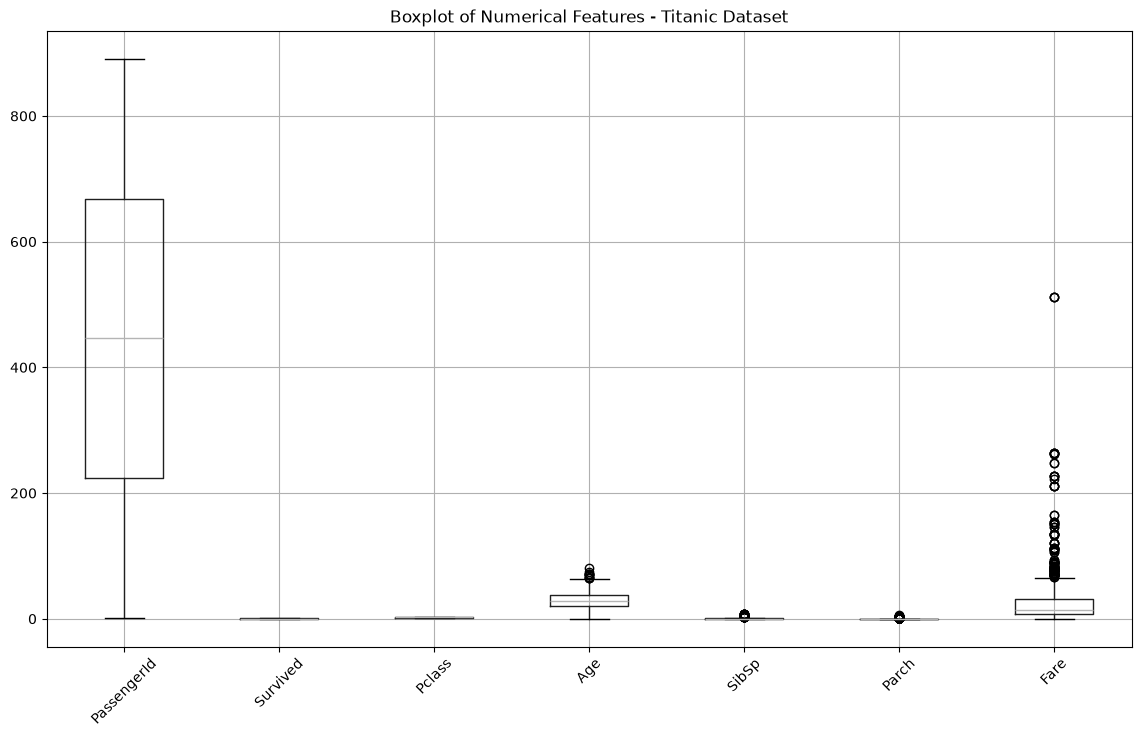

In [13]:
import matplotlib.pyplot as plt

# Numerical columns in Titanic dataset
numerical_columns = [
    "PassengerId",
    "Survived",
    "Pclass",
    "Age",
    "SibSp",
    "Parch",
    "Fare"
]

# Create boxplot
fig6 = plt.figure(figsize=(14, 8))

df[numerical_columns].boxplot()

plt.xticks(rotation=45)
plt.title("Boxplot of Numerical Features - Titanic Dataset")
plt.show()

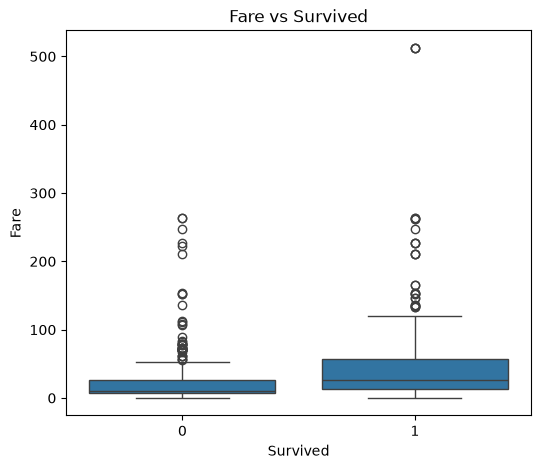

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,5))
fig7 = sns.boxplot(x='Survived', y='Fare', data=df)

plt.title("Fare vs Survived")
plt.show()

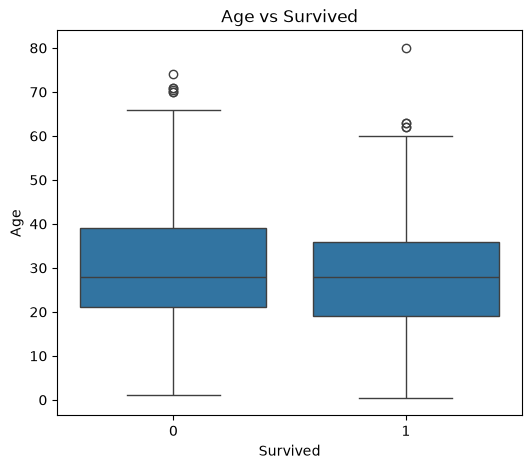

In [15]:
plt.figure(figsize=(6,5))
fig7 = sns.boxplot(x='Survived', y='Age', data=df)

plt.title("Age vs Survived")
plt.show()

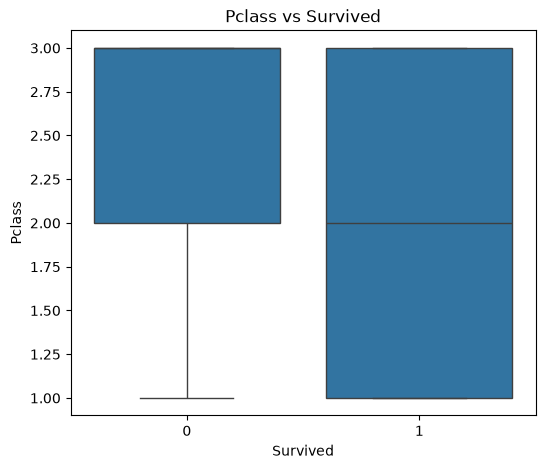

In [16]:
plt.figure(figsize=(6,5))
fig7 = sns.boxplot(x='Survived', y='Pclass', data=df)

plt.title("Pclass vs Survived")
plt.show()

In [18]:
fig1 = plt.figure(figsize=(8,6))
# plot 1

fig2 = plt.figure(figsize=(8,6))
# plot 2

fig3 = plt.figure(figsize=(8,6))
# plot 3

<Figure size 800x600 with 0 Axes>

<Figure size 800x600 with 0 Axes>

<Figure size 800x600 with 0 Axes>

In [20]:
from matplotlib.backends.backend_pdf import PdfPages

with PdfPages("EDA_Report.pdf") as pdf:

    pdf.savefig(fig2)
    pdf.savefig(fig3)
    pdf.savefig(fig6)
    

print("EDA Report saved successfully.")

EDA Report saved successfully.


In [21]:
from matplotlib.backends.backend_pdf import PdfPages
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

with PdfPages("Titanic_EDA_Report.pdf") as pdf:

    #------------------------------------------------------
    # Page 1 : Missing Value Heatmap
    #------------------------------------------------------
    plt.figure(figsize=(12,6))

    sns.heatmap(
        df.isnull(),
        cbar=True,
        yticklabels=False,
        cmap="viridis"
    )

    plt.title("Missing Value Heatmap")
    plt.xlabel("Features")
    plt.ylabel("Samples")

    pdf.savefig()
    plt.close()


    #------------------------------------------------------
    # Page 2 : Histograms
    #------------------------------------------------------
    numerical_features = [
        "Age",
        "Fare",
        "Pclass",
        "SibSp",
        "Parch"
    ]

    fig, axes = plt.subplots(3,2,figsize=(14,12))

    axes = axes.flatten()

    for i, col in enumerate(numerical_features):

        axes[i].hist(df[col].dropna(),
                     bins=15,
                     edgecolor='black')

        axes[i].set_title(col)

    # Hide unused subplot
    axes[-1].axis("off")

    plt.tight_layout()

    pdf.savefig()
    plt.close()


    #------------------------------------------------------
    # Page 3 : Survival by Passenger Class
    #------------------------------------------------------
    plt.figure(figsize=(8,6))

    sns.countplot(
        data=df,
        x="Pclass",
        hue="Survived"
    )

    plt.title("Survival Status by Passenger Class")

    pdf.savefig()
    plt.close()


    #------------------------------------------------------
    # Page 4 : Correlation Heatmap
    #------------------------------------------------------
    plt.figure(figsize=(8,6))

    corr = df.select_dtypes(include=np.number).corr()

    sns.heatmap(
        corr,
        annot=True,
        cmap="coolwarm",
        fmt=".2f"
    )

    plt.title("Correlation Heatmap")

    pdf.savefig()
    plt.close()


    #------------------------------------------------------
    # Page 5 : Boxplots
    #------------------------------------------------------
    fig, axes = plt.subplots(3,2,figsize=(14,12))

    axes = axes.flatten()

    for i, col in enumerate(numerical_features):

        sns.boxplot(
            y=df[col],
            ax=axes[i]
        )

        axes[i].set_title(col)

    # Hide unused subplot
    axes[-1].axis("off")

    plt.tight_layout()

    pdf.savefig()
    plt.close()

print("Titanic_EDA_Report.pdf created successfully.")

Titanic_EDA_Report.pdf created successfully.
